<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Hito3_CNN%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [67]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time
import copy
import torch.nn as nn
import torch.nn.functional as F
import torchvision

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [2]:
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
dfdata = pd.read_csv(url)
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
df_descriptions = pd.read_csv(url)

In [3]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfdata.owners[100])

'Lsell'

<Axes: xlabel='owners_label'>

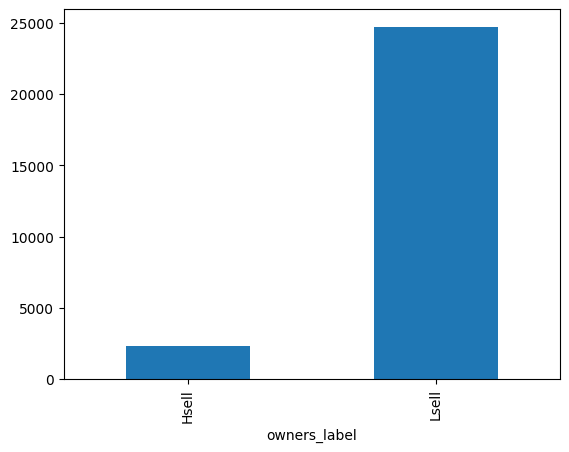

In [4]:
dfdata['owners_label'] = [ class_owners(i) for i in dfdata.owners ]
dfdata.groupby('owners_label').count().loc[:,'name'].plot.bar()

Seleccionamos un sample de 500 por cada clase

In [5]:
Nsample = 600
labels = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfdata.index[dfdata.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfdata.loc[ sum(list_ids,[]) , ['appid','name','genres','owners','owners_label'] ]
dfsample

,appid,name,genres,owners,owners_label
5923,377310,The Tower Of Elements,Action;Indie,200000-500000,Hsell
174,6870,Battlestations: Midway,Action,200000-500000,Hsell
1888,246900,Viscera Cleanup Detail,Indie;Simulation,500000-1000000,Hsell
14401,626690,Sword Art Online: Fatal Bullet,Action;RPG,200000-500000,Hsell
2775,285190,"Warhammer 40,000: Dawn of War III",Violent;Gore;Action;Simulation;Strategy,500000-1000000,Hsell
...,...,...,...,...,...
10044,502780,Avalon: The Journey Begins,Adventure;Indie,0-20000,Lsell
19784,784000,Let's be architects,Casual;Indie;Strategy,0-20000,Lsell
13505,598230,Ascender,Adventure;Indie,0-20000,Lsell
17241,710970,Learn (Japanese) Kana The Fun Way!,Casual;Indie,0-20000,Lsell


In [ ]:
list_img = []

for i in dfsample.appid:
  !wget https://cdn.cloudflare.steamstatic.com/steam/apps/{i}/header.jpg
  list_img.append(Image.open('header.jpg'))
  !rm header.jpg




# 1 Definicion de clases y transformaciones


In [69]:
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self, dataX, dataY, transform):
    self.transform = transform
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1

    self.classes = ['Lsell','Hsell']

    self.images = dataX
    self.labels = dataY

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    #image = Image.open(image_path)
    label = self.class2idx[self.labels[idx]]
    im = self.images[idx].convert('RGB')

    if self.transform:
      image = self.transform(im)

    return image, label

In [70]:
transforms = torchvision.transforms.Compose([torchvision.transforms.Resize(256),
                                 torchvision.transforms.CenterCrop(224),
                                 torchvision.transforms.ToTensor(),
                                 torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                      std=[0.229, 0.224, 0.225]) ] )

Split dataset en train, validation y test

In [100]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
X_train, X_test, Y_train, Y_test = train_test_split(list_img, ylabel, test_size = 0.1, stratify = ylabel , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/90, stratify= Y_train, random_state=seed)

Hsell


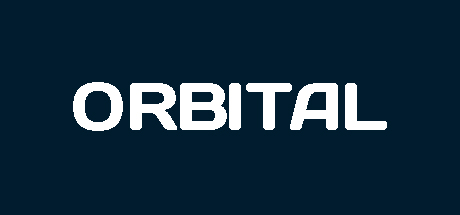

In [72]:
print(Y_train[63])
X_train[63]

In [114]:
# crear Games datasets
train_dataset = GamesDataset(dataX = X_train, dataY = Y_train , transform = transforms)
valid_dataset = GamesDataset(dataX = X_val, dataY = Y_val , transform = transforms)
test_dataset  = GamesDataset(dataX = X_test, dataY = Y_test , transform = transforms)
# dataloaders
batch_size = 50

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=1)

In [115]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


# 3. Entrenamiento de modelo preentrenado

In [116]:
def train_model(model,criterio,optimizer,scheduler,train_loader,train_data,val_loader,val_data,num_epochs = 100):
  since = time.time()
  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0
  best_acc_train = 0.0
  best_acc_val = 0.0
  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    #print('-' * 10)
    #Train model
    scheduler.step()
    model.train()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(train_data)
    epoch_acc_train = running_corrects.double() / len(train_data)
    print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc_train))
    #Validation
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(val_data)
    epoch_acc = running_corrects.double() / len(val_data)
    print('Val Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
    if epoch_acc > best_acc:
        best_acc_train = epoch_acc_train
        best_acc = epoch_acc
        best_acc_val = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
    if float(epoch_acc_train) - float(epoch_acc)  > 0.3:
      print('early stopping at epoch ',epoch)
      print(epoch_acc_train)
      print(epoch_acc)
      break
  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best val accucary: {:.4f}'.format(best_acc))
  print('Best train accucary: {:.4f}'.format(best_acc_train))
  print('--------------------------------------')
  print('--------------------------------------')
  print('--------------------------------------')
  model.load_state_dict(best_model_wts)
  return model,best_acc_train,best_acc_val

In [117]:
def predict_test(model,test_data):
    #Test
    model.eval()
    running_corrects = 0.0
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        #print(outputs)

      running_corrects += torch.sum(preds == labels.data)
      #print(running_corrects)

    acc_test = running_corrects.double() / len(test_data)
    return acc_test

In [118]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [119]:
rs= models.resnet18(pretrained=True)

In [121]:
pretrained = copy.deepcopy(rs)
nweights = 1000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)


tensor(0.5417, device='cuda:0', dtype=torch.float64)

Freezing

In [ ]:
pretrained = copy.deepcopy(rs)

for param in pretrained.parameters():
    param.requires_grad = False

nweights = 2000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(inumber),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)

